# STATISTICAL LEARNING FINAL PROJECT
## Raissa Kitenge

In [36]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/content/drive/MyDrive/feature_engineered_real_estate.csv')
df.head()

,TotalFinishedArea,LivingUnits,TotalAppraisedValue,SaleYear,SaleMonth,PriceRatio,AssrLandUse_APT FOUR,AssrLandUse_CONDOMINIMUM,AssrLandUse_MULTI DWLG,AssrLandUse_ONE FAMILY,AssrLandUse_THREE FAMILY,AssrLandUse_TWO FAMILY
0,1092.0,1.0,187200,2024,7,1.383547,False,False,False,True,False,False
1,936.0,1.0,192300,2022,4,1.081643,False,False,False,True,False,False
2,1111.0,1.0,148400,2023,12,0.842318,False,False,False,True,False,False
3,1684.0,1.0,197900,2021,1,0.894391,False,False,False,True,False,False
4,900.0,1.0,170700,2021,9,1.101347,False,False,False,True,False,False


# Step 1

In [37]:
# Check data
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(3137, 12)
Index(['TotalFinishedArea', 'LivingUnits', 'TotalAppraisedValue', 'SaleYear',
       'SaleMonth', 'PriceRatio', 'AssrLandUse_APT FOUR',
       'AssrLandUse_CONDOMINIMUM', 'AssrLandUse_MULTI DWLG',
       'AssrLandUse_ONE FAMILY', 'AssrLandUse_THREE FAMILY',
       'AssrLandUse_TWO FAMILY'],
      dtype='object')
TotalFinishedArea           0
LivingUnits                 0
TotalAppraisedValue         0
SaleYear                    0
SaleMonth                   0
PriceRatio                  0
AssrLandUse_APT FOUR        0
AssrLandUse_CONDOMINIMUM    0
AssrLandUse_MULTI DWLG      0
AssrLandUse_ONE FAMILY      0
AssrLandUse_THREE FAMILY    0
AssrLandUse_TWO FAMILY      0
dtype: int64


In [38]:
# Define response and predictors
y_col = "PriceRatio"

x_cols = [
    "TotalFinishedArea",
    "LivingUnits",
    "SaleYear",
    "SaleMonth",
    "AssrLandUse_APT FOUR",
    "AssrLandUse_CONDOMINIMUM",
    "AssrLandUse_MULTI DWLG",
    "AssrLandUse_THREE FAMILY",
    "AssrLandUse_TWO FAMILY"
]

In [39]:
df = df[[y_col] + x_cols].copy()

In [40]:
# Split into training and test sets
df_train, df_test = train_test_split(df, test_size=0.2, random_state=6243)

print(df_train.shape)
print(df_test.shape)

(2509, 10)
(628, 10)


In [41]:
# Standardize only the continuous predictors
cont_cols = [
    "TotalFinishedArea",
    "LivingUnits",
    "SaleYear",
    "SaleMonth"
]

scaler = StandardScaler()

df_train = df_train.copy()
df_test = df_test.copy()

df_train[cont_cols] = scaler.fit_transform(df_train[cont_cols])
df_test[cont_cols] = scaler.transform(df_test[cont_cols])

df_train.head()

,PriceRatio,TotalFinishedArea,LivingUnits,SaleYear,SaleMonth,AssrLandUse_APT FOUR,AssrLandUse_CONDOMINIMUM,AssrLandUse_MULTI DWLG,AssrLandUse_THREE FAMILY,AssrLandUse_TWO FAMILY
625,0.788397,0.987019,0.338207,-0.012819,0.670056,False,False,False,False,True
2623,1.022044,1.197209,1.494284,-0.882083,0.956213,False,False,False,True,False
211,1.122914,-1.160396,-0.817871,-0.012819,0.670056,False,False,False,False,False
2552,0.669291,0.374654,0.338207,-0.882083,-0.474571,False,False,False,False,True
1687,0.988372,-1.122330,-0.817871,-0.012819,-0.188414,False,True,False,False,False


# Step 2

In [42]:
with pm.Model() as bayes_model:
    # Priors
    intercept = pm.StudentT("Intercept", nu=4, mu=0, sigma=10)

    w_TotalFinishedArea   = pm.Normal("w_TotalFinishedArea", mu=0, sigma=10)
    w_LivingUnits         = pm.Normal("w_LivingUnits", mu=0, sigma=10)
    w_SaleYear            = pm.Normal("w_SaleYear", mu=0, sigma=10)
    w_SaleMonth           = pm.Normal("w_SaleMonth", mu=0, sigma=10)

    w_APT_FOUR            = pm.Normal("w_APT_FOUR", mu=0, sigma=10)
    w_CONDOMINIMUM        = pm.Normal("w_CONDOMINIMUM", mu=0, sigma=10)
    w_MULTI_DWLG          = pm.Normal("w_MULTI_DWLG", mu=0, sigma=10)
    w_THREE_FAMILY        = pm.Normal("w_THREE_FAMILY", mu=0, sigma=10)
    w_TWO_FAMILY          = pm.Normal("w_TWO_FAMILY", mu=0, sigma=10)

    sigma = pm.HalfNormal("sigma", sigma=1)

    # Linear predictor
    mu = (
        intercept
        + w_TotalFinishedArea   * df_train["TotalFinishedArea"]
        + w_LivingUnits         * df_train["LivingUnits"]
        + w_SaleYear            * df_train["SaleYear"]
        + w_SaleMonth           * df_train["SaleMonth"]
        + w_APT_FOUR            * df_train["AssrLandUse_APT FOUR"]
        + w_CONDOMINIMUM        * df_train["AssrLandUse_CONDOMINIMUM"]
        + w_MULTI_DWLG          * df_train["AssrLandUse_MULTI DWLG"]
        + w_THREE_FAMILY        * df_train["AssrLandUse_THREE FAMILY"]
        + w_TWO_FAMILY          * df_train["AssrLandUse_TWO FAMILY"]
    )

    # Likelihood
    y_obs = pm.Normal("PriceRatio", mu=mu, sigma=sigma, observed=df_train[y_col])

    # Posterior sampling
    trace_bayes = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        random_seed=6243,
        target_accept=0.9,
        return_inferencedata=True
    )

Output()

# Step 3

In [43]:
# Posterior summaries

# Summary table
summary = az.summary(trace_bayes, round_to=4)
print(summary)

                       mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
Intercept            1.1208  0.0259  1.0733   1.1683     0.0012   0.0007   
sigma                0.2052  0.0028  0.1997   0.2104     0.0001   0.0001   
w_APT_FOUR          -0.0586  0.1165 -0.2637   0.1513     0.0053   0.0030   
w_CONDOMINIMUM       0.0222  0.0123 -0.0001   0.0460     0.0003   0.0002   
w_LivingUnits        0.0655  0.0307  0.0066   0.1199     0.0014   0.0008   
w_MULTI_DWLG        -0.1087  0.1186 -0.3375   0.1021     0.0036   0.0026   
w_SaleMonth          0.0172  0.0044  0.0087   0.0252     0.0001   0.0001   
w_SaleYear           0.0868  0.0044  0.0789   0.0955     0.0001   0.0001   
w_THREE_FAMILY      -0.0976  0.0723 -0.2282   0.0352     0.0034   0.0019   
w_TWO_FAMILY        -0.0665  0.0375 -0.1348   0.0033     0.0018   0.0010   
w_TotalFinishedArea -0.0241  0.0067 -0.0373  -0.0120     0.0002   0.0001   

                      ess_bulk   ess_tail   r_hat  
Intercept             462.3047   69

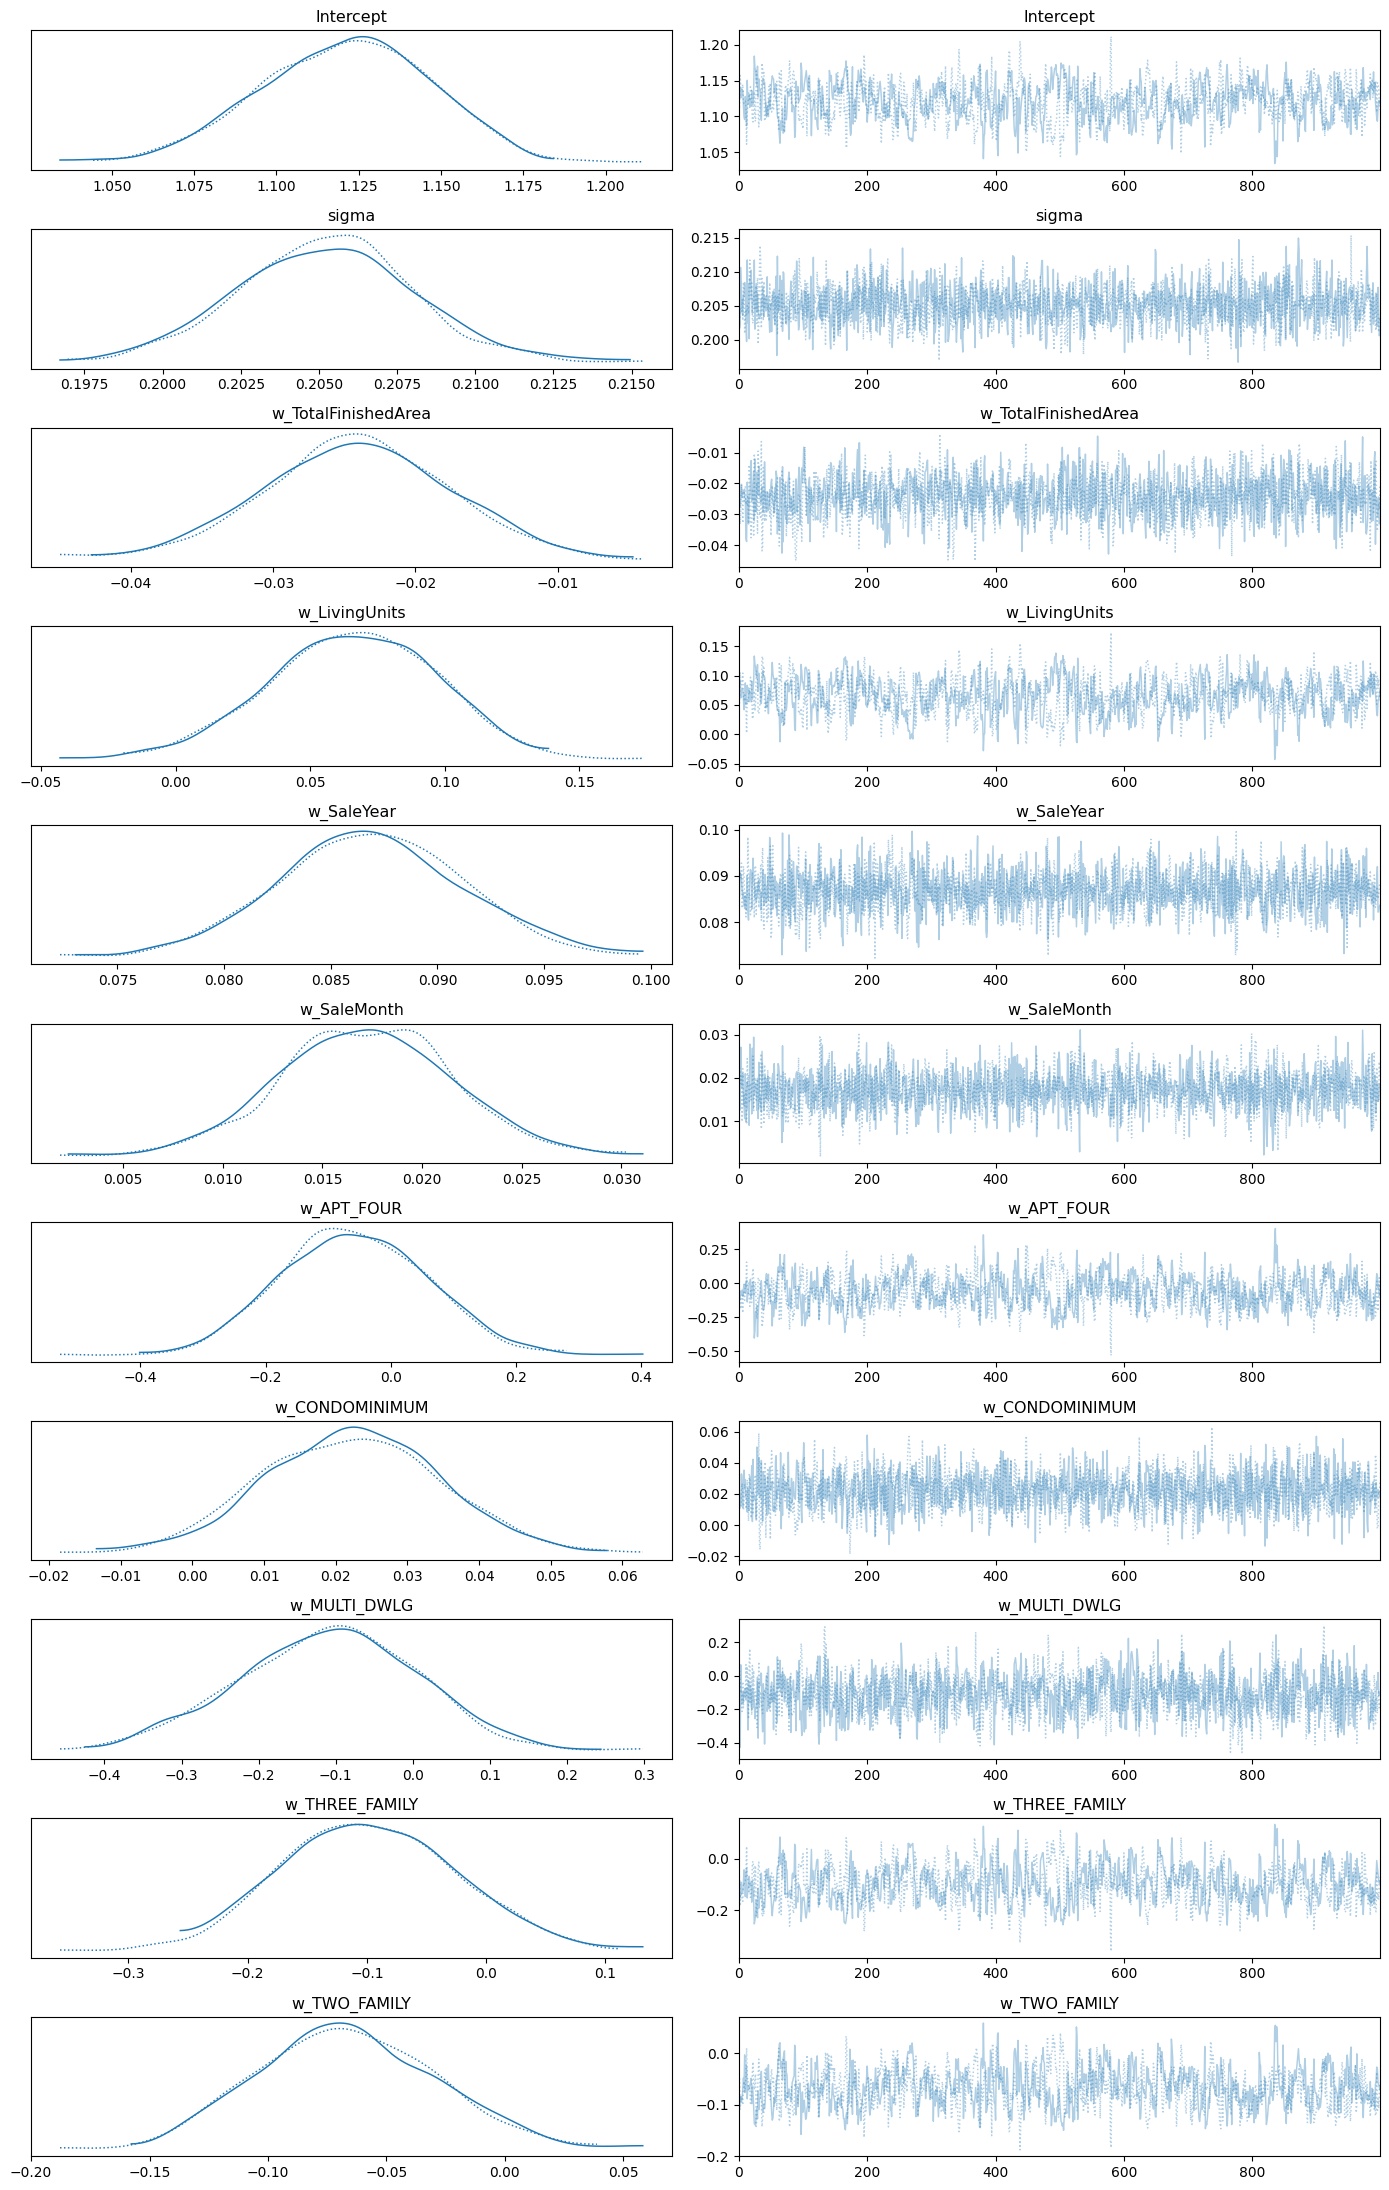

In [44]:
az.plot_trace(
    trace_bayes,
    var_names=[
        "Intercept", "sigma",
        "w_TotalFinishedArea", "w_LivingUnits",
        "w_SaleYear", "w_SaleMonth",
        "w_APT_FOUR", "w_CONDOMINIMUM", "w_MULTI_DWLG",
        "w_THREE_FAMILY", "w_TWO_FAMILY"
    ],
    figsize=(14, 22)
)
plt.tight_layout()
plt.show()

In [45]:
!apt-get update
!apt-get install -y texlive-xetex texlive-fonts-recommended texlive-plain-generic


Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:4 https://cli.github.com/packages stable InRelease
Hit:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:7 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
texlive-fonts-recommended is already the newest version (2021.20220204-1).
texlive-plain-gener

In [46]:
!jupyter nbconvert --to pdf '/content/drive/MyDrive/Colab Notebooks/07_bayesian_model.ipynb'

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/07_bayesian_model.ipynb to pdf
[NbConvertApp] Support files will be in 07_bayesian_model_files/
[NbConvertApp] Making directory ./07_bayesian_model_files
[NbConvertApp] Writing 42611 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 984671 bytes to /content/drive/MyDrive/Colab Notebooks/07_bayesian_model.pdf
